In [159]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [160]:
np.random.seed(42)
n = 300


size             = np.random.randint(500,4000, n)
bedrooms         = np.random.randint(1,6,n)
age              = np.random.randint(0,50,n)
location_score   = np.random.randint(1,11,n)
garage           = np.random.randint(0,2,n)

noise = np.random.normal(0,15000, n)

price = (150 * size) + (8000 * bedrooms) - (500 * age) + (10000 * location_score) + (20000 * garage) + noise

df = pd.DataFrame({
    'size'           : size,
    'bedrooms'       : bedrooms,
    'age'            : age,
    'location_score' : location_score,
    'garage'         : garage,
    'price'          : price
})


print("Dataset Shape :", df.shape)
df.head(10)



Dataset Shape : (300, 6)


,size,bedrooms,age,location_score,garage,price
0,3674,4,46,9,1,665483.215750
1,1360,1,15,10,1,314616.523670
2,1794,1,4,9,1,395056.058208
3,1630,2,34,9,0,348652.121906
4,1595,1,11,6,0,288720.892161
5,3592,3,24,8,0,631471.503006
6,2138,4,20,1,0,371967.995509
7,2669,1,35,10,1,521185.543048
8,966,1,22,4,0,194465.461576
9,1738,2,15,1,0,299719.779612


In [161]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(300, 6)
size                int32
bedrooms            int32
age                 int32
location_score      int32
garage              int32
price             float64
dtype: object
size              0
bedrooms          0
age               0
location_score    0
garage            0
price             0
dtype: int64


In [162]:
df.describe()

,size,bedrooms,age,location_score,garage,price
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2341.816667,2.950000,23.806667,5.650000,0.483333,430641.734230
std,995.267929,1.447232,14.582345,2.834481,0.500557,153669.232865
min,501.000000,1.000000,0.000000,1.000000,0.000000,107578.441524
25%,1535.500000,2.000000,11.000000,3.000000,0.000000,306842.551620
50%,2281.000000,3.000000,24.000000,6.000000,0.000000,425120.045615
75%,3231.750000,4.000000,36.000000,8.000000,1.000000,561949.137397
max,3999.000000,5.000000,49.000000,10.000000,1.000000,725422.561102


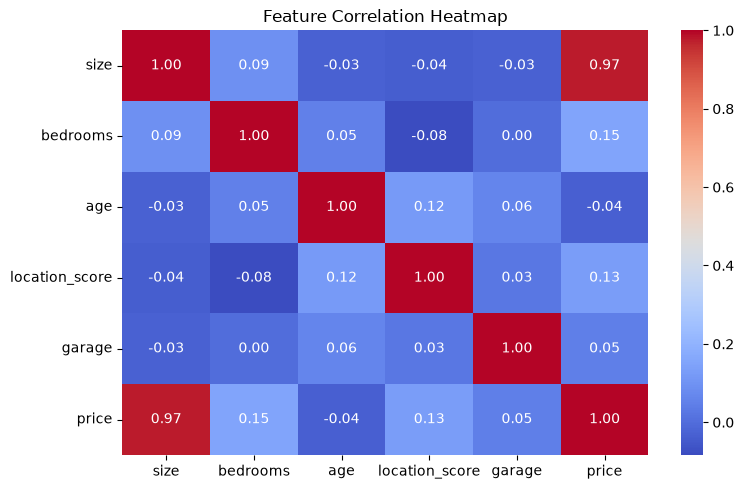

In [163]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot = True, fmt='0.2f', cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

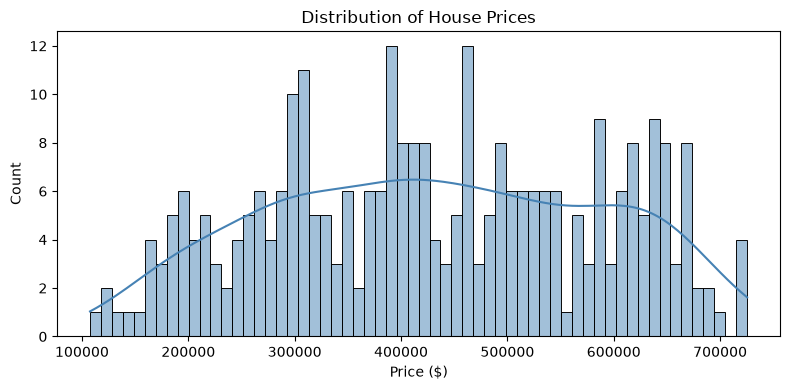

In [164]:
plt.figure(figsize=(8,4))
sns.histplot(df['price'], bins=60, kde=True, color='steelblue')
plt.title("Distribution of House Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

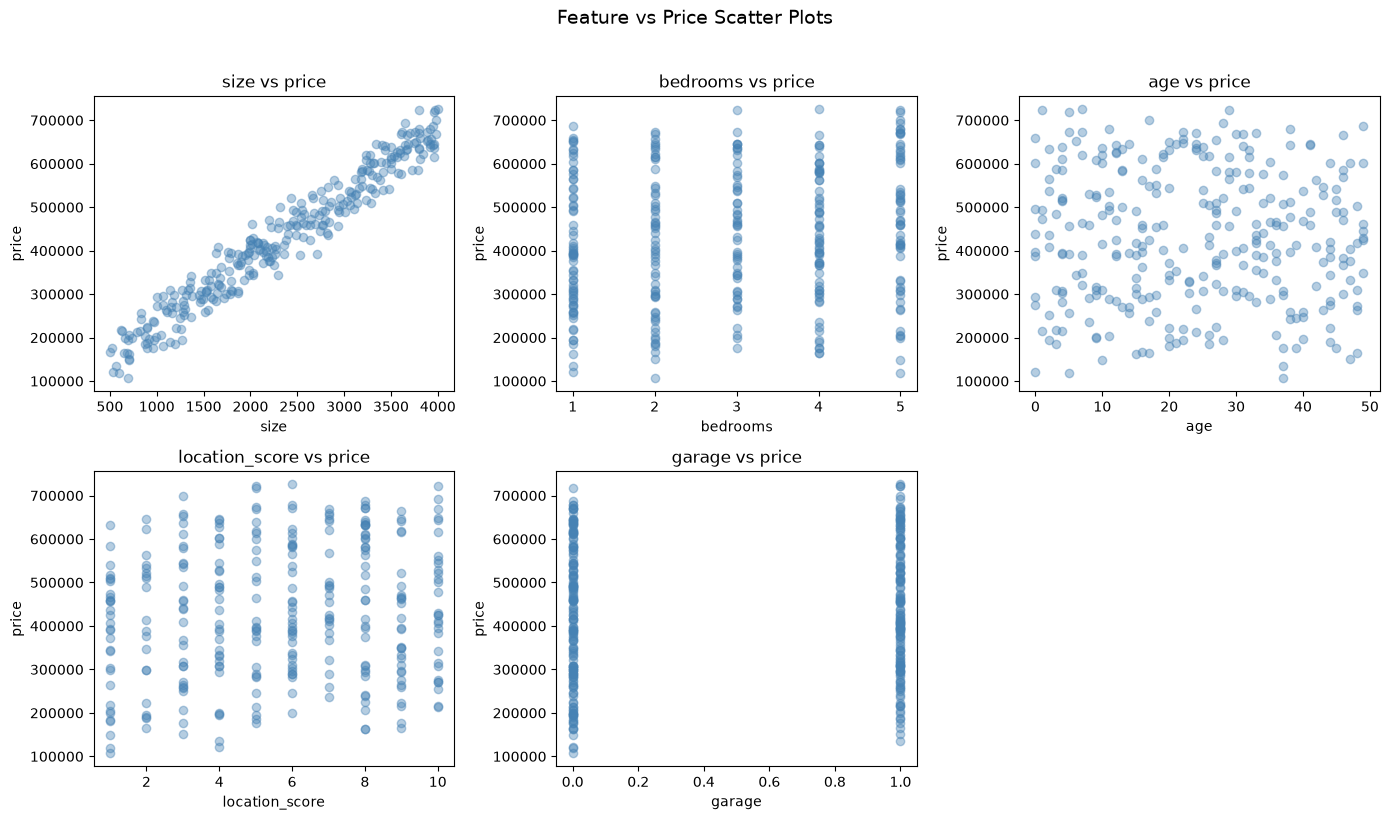

In [165]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

features = ['size', 'bedrooms', 'age', 'location_score', 'garage']

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['price'], alpha=0.4, color='steelblue')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('price')
    axes[i].set_title(f"{feature} vs price")

axes[5].axis('off')

plt.suptitle("Feature vs Price Scatter Plots", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
    

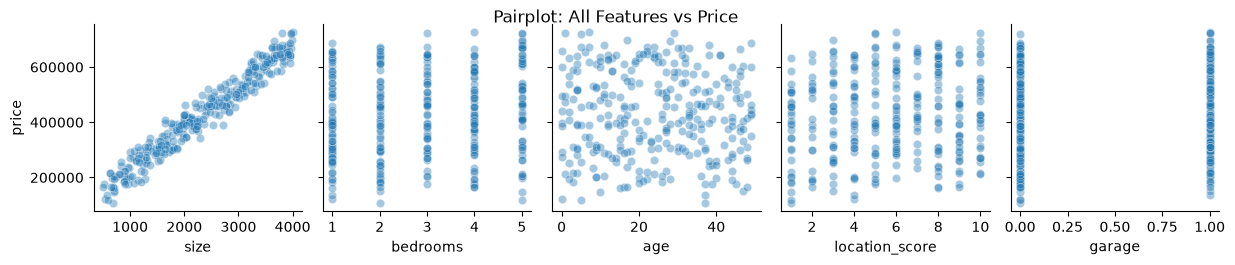

In [166]:
sns.pairplot(df, y_vars=['price'], x_vars=['size', 'bedrooms', 'age', 'location_score', 'garage'],
             plot_kws={'alpha': 0.4})
plt.suptitle("Pairplot: All Features vs Price", y=1.02)
plt.show()


In [167]:
x = df.drop('price', axis=1)
y = df['price']

print("X shape", x.shape)
print("Y shape", y.shape)
print()

print("Feature (X):")
print(x.head(3))
print()
print("Target (y):")
print(y.head(3))

X shape (300, 5)
Y shape (300,)

Feature (X):
   size  bedrooms  age  location_score  garage
0  3674         4   46               9       1
1  1360         1   15              10       1
2  1794         1    4               9       1

Target (y):
0    665483.215750
1    314616.523670
2    395056.058208
Name: price, dtype: float64


In [168]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

print("Traning set size", x_train.shape)
print("Testing set size", x_test.shape)
print()
print("Training prices", y_train.shape)
print("Testing prices", y_test.shape)

Traning set size (240, 5)
Testing set size (60, 5)

Training prices (240,)
Testing prices (60,)


In [169]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

print("Before scaling — first training row:")
print(x_train.iloc[0].values)

print()
print("After scaling — same row:")
print(x_train_scaled[0].round(3))

Before scaling — first training row:
[1995    2   17   10    1]

After scaling — same row:
[-0.329 -0.667 -0.471  1.513  1.025]


In [170]:
print("X_train_scaled shape:", x_train_scaled.shape)   # (240, 5)
print("X_test_scaled shape: ", x_test_scaled.shape)    # (60, 5)

print()
print("Mean of each feature (training, after scaling):")
print(x_train_scaled.mean(axis=0).round(3))   # should be near [0, 0, 0, 0, 0]

print()
print("Std of each feature (training, after scaling):")
print(x_train_scaled.std(axis=0).round(3))    # should be near [1, 1, 1, 1, 1]


X_train_scaled shape: (240, 5)
X_test_scaled shape:  (60, 5)

Mean of each feature (training, after scaling):
[-0. -0.  0.  0. -0.]

Std of each feature (training, after scaling):
[1. 1. 1. 1. 1.]


In [171]:
model = LinearRegression()
model.fit(x_train_scaled,y_train)

print(" Model trained successfully!")
print()
print("Intercept (b):", round(model.intercept_, 2))

 Model trained successfully!

Intercept (b): 428226.31


In [172]:

coefficients = pd.DataFrame({
    'Feature'    : x.columns,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values('Coefficient', ascending=False)
print(coefficients.to_string(index=False))


       Feature   Coefficient
          size 152125.597449
location_score  27673.155136
        garage  11506.633535
      bedrooms  11450.519513
           age  -5968.751433


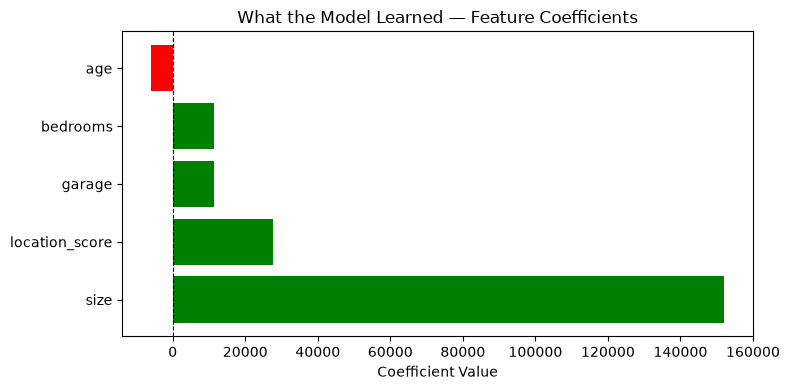

In [173]:

plt.figure(figsize=(8, 4))
colors = ['green' if c > 0 else 'red' for c in coefficients['Coefficient']]

plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel("Coefficient Value")
plt.title("What the Model Learned — Feature Coefficients")
plt.tight_layout()
plt.show()


In [174]:
sample_house = x_test_scaled[0].reshape(1, -1)   
actual_price  = y_test.iloc[0]
predicted_price = model.predict(sample_house)[0]

print(f"Actual Price:    ${actual_price:>12,.0f}")
print(f"Predicted Price: ${predicted_price:>12,.0f}")
print(f"Difference:      ${abs(actual_price - predicted_price):>12,.0f}")


Actual Price:    $     398,140
Predicted Price: $     374,917
Difference:      $      23,223


In [175]:

y_pred = model.predict(x_test_scaled)

print("First 5 actual prices:   ", y_test.values[:5].round(0))
print("First 5 predicted prices:", y_pred[:5].round(0))


First 5 actual prices:    [398140. 308781. 281424. 299720. 722578.]
First 5 predicted prices: [374917. 269378. 288272. 265047. 707323.]


In [176]:

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("       MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"  MAE  : ${mae:>12,.0f}")
print(f"  MSE  : ${mse:>12,.0f}")
print(f"  RMSE : ${rmse:>12,.0f}")
print(f"  R²   : {r2:>13.4f}")
print("=" * 40)


       MODEL EVALUATION RESULTS
  MAE  : $      19,547
  MSE  : $ 576,119,388
  RMSE : $      24,002
  R²   :        0.9731


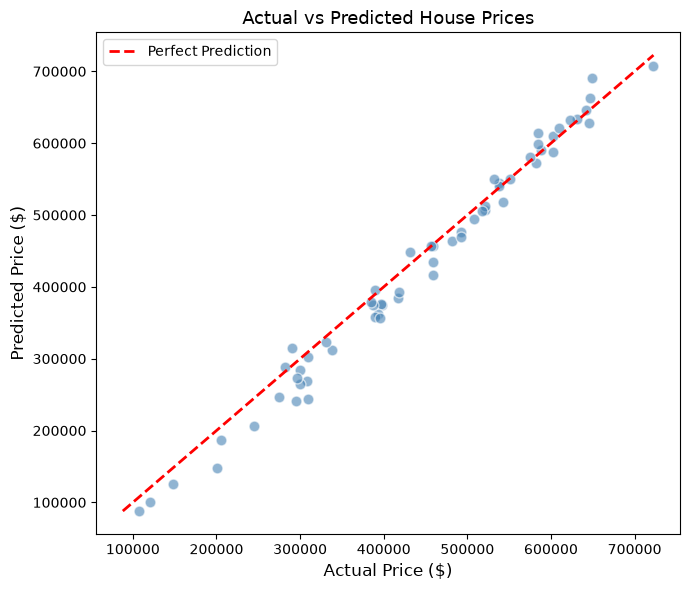

In [177]:

plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', s=60)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual Price ($)", fontsize=12)
plt.ylabel("Predicted Price ($)", fontsize=12)
plt.title("Actual vs Predicted House Prices", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()


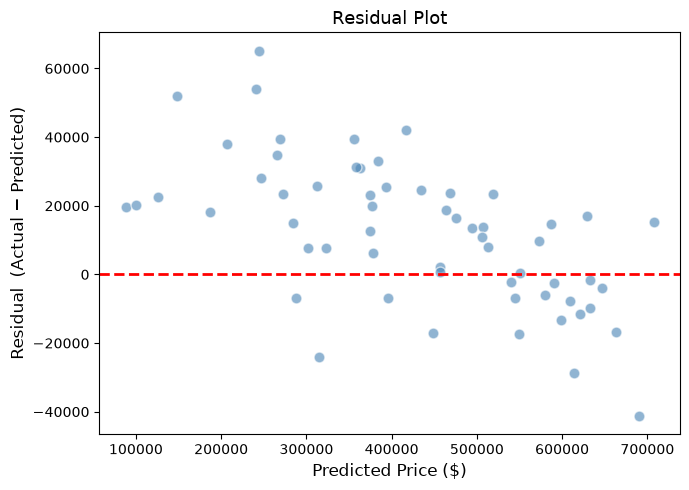

In [178]:
residuals = y_test.values - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.6, color='steelblue', edgecolors='white', s=60)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted Price ($)", fontsize=12)
plt.ylabel("Residual  (Actual − Predicted)", fontsize=12)
plt.title("Residual Plot", fontsize=13)
plt.tight_layout()
plt.show()


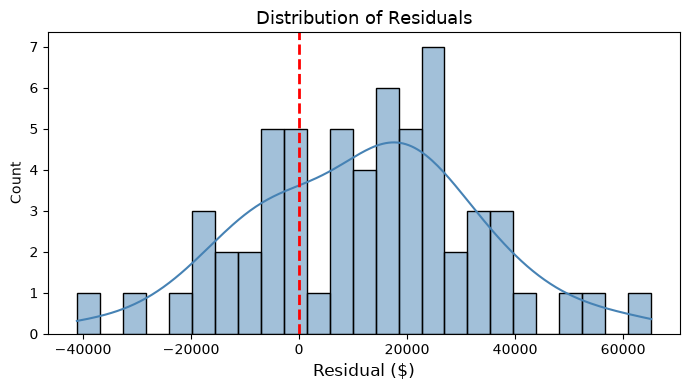

Mean of residuals: $12,077  (should be near 0)


In [179]:

plt.figure(figsize=(7, 4))
sns.histplot(residuals, bins=25, kde=True, color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Residual ($)", fontsize=12)
plt.title("Distribution of Residuals", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Mean of residuals: ${residuals.mean():,.0f}  (should be near 0)")


In [180]:
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0)

ridge.fit(x_train_scaled, y_train)
lasso.fit(x_train_scaled, y_train)

print("✅ Ridge trained!")
print("✅ Lasso trained!")

✅ Ridge trained!
✅ Lasso trained!


In [ ]:

models = {
    'Linear Regression': model,
    'Ridge             ': ridge,
    'Lasso             ': lasso
}

print("=" * 55)
print(f"  {'Model':<25} {'R²':>8}  {'RMSE':>14}")
print("=" * 55)

for name, m in models.items():
    y_p  = m.predict(x_test_scaled)
    r2   = r2_score(y_test, y_p)
    rmse = np.sqrt(mean_squared_error(y_test, y_p))
    print(f"  {name:<25} {r2:>8.4f}  ${rmse:>12,.0f}")

print("=" * 55)


  Model                           R²            RMSE
  Linear Regression           0.9731  $      24,002
  Ridge                       0.9738  $      23,650
  Lasso                       0.9731  $      24,002


Finally understanding

In [184]:
new_house = pd.DataFrame({
    'size'          : [2000],
    'bedrooms'      : [3],
    'age'           : [10],
    'location_score': [7],
    'garage'        : [1]
})

print("New house details:")
print(new_house.to_string(index=False))

New house details:
 size  bedrooms  age  location_score  garage
 2000         3   10               7       1


In [185]:

new_house_scaled = scaler.transform(new_house)   # transform only — never fit again!

pred_lr    = model.predict(new_house_scaled)[0]
pred_ridge = ridge.predict(new_house_scaled)[0]
pred_lasso = lasso.predict(new_house_scaled)[0]

print("=" * 45)
print("     HOUSE PRICE PREDICTIONS")
print("=" * 45)
print(f"  Linear Regression : ${pred_lr:>12,.0f}")
print(f"  Ridge             : ${pred_ridge:>12,.0f}")
print(f"  Lasso             : ${pred_lasso:>12,.0f}")
print("=" * 45)


     HOUSE PRICE PREDICTIONS
  Linear Regression : $     398,331
  Ridge             : $     398,401
  Lasso             : $     398,328
